# Introducción a Gurobi 

Gurobi es un software de optimización diseñado para encontrar soluciones de la forma más eficiente posible. Es uno de los mejores optimizadores que están en el estado del arte. 

Para poder obtener acceso es necesario obtener una licencia académica, puesto que es un software privado.

Gurobi está compuesto por: 

1. **Front-end**: Donde definimos el modelo (variables, restricciones, función objetivo).
2. **Motor de optimización**: encargado de aplicar algoritmos (Simplex, Branch-and-Bound, etc)
3. **Interfaz de usuario**: APIs en Python, C, C++, Java, etc.

## *¿Cómo funciona Gurobi?*

Se definen variables de decisión, una función objetivo, y restricciones lineales o cuadráticas. 

Antes de empezar a resolver, el solver entra a una etapa de **preprocesamiento** donde Gurobi elimina redundancias, fija variables triviales y reduce el tamaño del problema. 

Para algoritmos LP / QP, se aplican métodos como **simplex** o **punto interior**. Para **MIP** utiliza técnicas como:

- **Branch-and-Bound**: Exploración de nodos del árbol de búsqueda.
- **Cortes**: Para reducir factibilidad de soluciones fraccionales.
- **Heurísticas**: Para encontrar incumbentes rápidamente.
- **Presolve**: Para mejorar la formulación antes de resolver.

El usuario tiene varias formas de intervenir con parámetros, como `MIPGap`, `TimeLimit`, `Heuristics`, **o intervenir directamente durante la optimización con callbacks**.

## *¿Qué son los callbacks?*

Una función que define el usuario que permite:
- **Monitoreo** (`where == GRB.Callback.MESSAGE`, `MIP`, `MIPNODE`)
- **Cortes de usuario** (`cbCut`) en `MIPNODE` (nodo con solución LP)
- **Restricciones perezosas** (`cbLazy`) en `MIPSOL` (incumbente entera)
- **Proveer soluciones heurísticas** (`cbSetSolution`)
- **Alcanzar logs personalizados y métricas de convergencia**

Un callback se define como una función genérica de Python que recibe los argumentos `model` y `where`. 

`model` es el argumento que recibe el objeto optimizador de Gurobi, mientras que `where`, es el lugar en el algoritmo (de Branch and Bound), de donde se llama la función.


In [1]:
def my_callback(model, where):
    if where == GRB.Callback.MIP:
        # Progreso global de MIP
        objbst = model.cbGet(GRB.Callback.MIP_OBJBST)
        objbnd = model.cbGet(GRB.Callback.MIP_OBJBND)
        nodecnt = model.cbGet(GRB.Callback.MIP_NODCNT)
        model._last_gap = abs(objbst - objbnd) / (1 + abs(objbst))
        # imprimir ocasionalmente
        if nodecnt % 1000 == 0:
            print(f"Nodes: {nodecnt}, Best: {objbst:.2f}, Bound: {objbnd:.2f}")
    elif where == GRB.Callback.MIPSOL:
        # Solución entera encontrada (incumbente)
        # se pueden chequear violaciones y añadir lazy constraints
        pass
    elif where == GRB.Callback.MIPNODE:
        # Nodo del árbol, solución de relajación disponible
        # se pueden cortar con cbCut
        pass
    elif where == GRB.Callback.MESSAGE:
        # Leer línea de log si se desea
        msg = model.cbGet(GRB.Callback.MSG_STRING)
        # print(msg.strip())
        pass

Partamos con un breve ejemplo sobre un problema TSP. Primero, llamamos el objeto que encontrará la solución:

In [21]:
import gurobipy as gp
import numpy as np
from gurobipy import GRB

m = gp.Model("Auxiliar 6")

Podemos definirnos un diccionario de parámetros para pasarselos al solver:

In [3]:
params = {
    # === DESACTIVAR COSAS ===
    "Heuristics": 0.0,  # 0 desactiva heurísticas internas
    "Cuts": 0,  # 0 desactiva cortes
    "Presolve": 0,  # 0 desactiva presolve (2 agresivo, -1 auto)
    "Symmetry": 0,  # 0 desactiva detección de simetría
    "ConcurrentMIP": 1,  # 1 desactiva concurrente (corre estrategias distintas en paralelo)
    # === FOCO DE BÚSQUEDA ===
    "MIPFocus": 0,  # 0 auto, 1 incumbente rápido, 2 gap, 3 bound
    "VarBranch": 0,  # 0 auto, 1 max infeas, 2 pseudo cost; como se elige la variable actual para hacer branching
    "NodeMethod": 1,  # 1 dual simplex en nodos (0 auto, 2 barrier); como se resuelve el LP en los nodos
    "BranchDir": 0,  # 0 auto, 1 up, -1 down
    # === TOLERANCIAS ===
    "MIPGap": 0.0,  # gap objetivo relativo deseado (p.ej. 0.01 = 1%)
    "FeasibilityTol": 1e-6,  # tolerancia de viabilidad
    "IntFeasTol": 1e-5,  # tolerancia de integralidad
    "NumericFocus": 0,  # 0-3 (3 = más robusto numéricamente)
    # === LÍMITES Y LOG ===
    "TimeLimit": 60,  # seg. (0 = sin límite)
    "BestObjStop": None,  # para minimización: detiene al llegar a obj <= valor
    "BestBdStop": None,  # detiene si bound <= valor
    "Threads": 0,  # 0 = auto
    "Seed": 42,
    "LogToConsole": 1,  # 1 muestra log, 0 oculta
}

for k, v in params.items():
    if v is not None:
        m.setParam(k, v)

Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Symmetry to value 0
Set parameter ConcurrentMIP to value 1
Set parameter MIPFocus to value 1
Set parameter VarBranch to value 0
Set parameter NodeMethod to value 1
Set parameter BranchDir to value 0
Set parameter MIPGap to value 0
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-05
Set parameter NumericFocus to value 0
Set parameter TimeLimit to value 60
Set parameter Threads to value 0
Set parameter Seed to value 42
Set parameter LogToConsole to value 1


Veamos como funciona esto en un problema de knapsack

In [4]:
from helpers import instancia_knapsack

N = 150
M = 3

v, W, caps = instancia_knapsack(
    n=N, m=M, density=0.56, seed=42
)  # density más baja = más difícil

En este caso, utilizaremos una **heurística de reparación**. Es decir, dado una solución fraccional vamos a buscar una forma rápida de obtener una solución entera. La idea es redondear la solución de forma que luego la arreglamos para cumplir factibilidad. 

Para el caso del knapsack, sabemos que la solución entera es de la forma $[0,1]^n$. De todas formas, este algoritmo se puede propagar a otros tipos de problemas.

Como input, recibimos una solución $\vec{x}$ fraccional de algún nodo. Por lo mismo, a esta solución $x^{LP}$ le aplicaremos el siguiente esquema de redondeo:

$$
x = \begin{cases} 
1&si\;x_{i}^{LP} >0.5\\ \\
0&\text{si no}
\end{cases}
$$

Ahora, por temas de notación, nos definiremos las restricciones de la siguiente forma: 

$$\sum_i w_{ki}x_i\leq C_i$$ 

Por lo mismo, intentaremos **medir la violación del redondeo**. Basicamente, nos definiremos:

$$\text{Viol}_k:=\max\lbrace 0, \sum w_{ki}x_i - C_k$$ 

Luego, entramos a la fase de reparación a la violación. Consideraremos que, para cada item seleccionado $(x_i=1)$, existe un "alivio" por restricción. El alivio se definirá como: 

$$\text{Alivio}_k:=\min (w_{ki}, \text{Viol}_k)$$

Por el otro lado, $\text{Alivio total}$ se definirá como la suma de todos los alivios en todas las restricciones. 

Por consiguiente, nos definimos un "score de remover", donde ordenaremos con un puntaje según el beneficio del item:

$$\text{Score de remover}:=\frac{v_i}{\text{Alivio total}}$$ 

Donde $v_i$ es el beneficio asociado al item $i$. 

Así, quitamos el peor ítem y reiteramos el algoritmo hasta que no hayan violaciones. 

Por último, una vez somos factibles, intentar añadir nuevas soluciones si es que se sigue cumpliendo la capacidad/factibilidad. 

In [5]:
def greedy_repair(x_rel, v, W, caps):
    """
    x_rel: vector fraccional LP del nodo
    v: valores de los ítems (para max, se puede llegar a su análogo en min)
    W: pesos (m x n)
    caps: capacidades (m)
    Devuelve x_bin factible (lista de 0/1) o None si algo falla.
    """
    n = len(x_rel)
    m = W.shape[0]
    # 1) Punto de partida: redondeo por umbral
    x = np.zeros(n, dtype=int)
    x[x_rel > 0.5] = 1 # Solución redondeada

    def overuse(x):
        use = (
            W @ x
        )  # Operación matricial que nos devuelve un vector en R^m con usos por restricción
        return use - caps  # Si es positivo hay violación

    def feasible(x):
        return np.all((W @ x) <= caps + 1e-9)  # Nos dice si hay factibilidad

    viol = overuse(x)
    if np.any(viol > 0):  # Loop, mientras existan violaciones
        # Mientras exista violación, saca el ítem “menos eficiente” para aliviar
        # Definimos score_rem = (v_i perdido) / (alivio total en suma de violaciones)
        # Cuanto menor el alivio por valor perdido, peor.
        while True:
            viol = overuse(x)
            if np.all(viol <= 0):
                break
            # candidatos a remover: índices con x_i=1
            idxs = np.where(x == 1)[0]  # Obtenemos los IDS de candidatos a remover
            if idxs.size == 0:
                return None  # sin arreglo
            scores = []
            viol_pos = np.maximum(
                viol, 0
            )  # Nos definimos violación donde hay, 0 donde no está activada
            for i in idxs:
                alivio = (W[:, i] > 0).astype(int) * W[:, i]
                # alivio “útil” solo donde hay violación
                alivio_util = np.minimum(alivio, viol_pos)
                alivio_total = np.sum(alivio_util)
                if alivio_total <= 0:  # no ayuda a violaciones actuales
                    sc = float("inf")
                else:
                    sc = v[i] / alivio_total
                scores.append((sc, i))  # Vector de scores
            # remover el peor (mayor score => v alto por poco alivio)
            scores.sort(reverse=True)
            _, i_bad = scores[0]
            x[i_bad] = 0

    # Si hay holgura, intentar agregar ítems (greedy por v/peso)
    # ordena ítems que están fuera por un “score” agregado
    outside = np.where(x == 0)[0]
    # score agregado tipo ratio con media de pesos (para m>1)
    mean_w = W[:, outside].mean(axis=0)
    # Evitar división por cero
    mean_w = np.where(mean_w <= 0, 1, mean_w)
    ratio = v[outside] / mean_w
    order = outside[np.argsort(-ratio)]
    for i in order:
        x_try = x.copy()
        x_try[i] = 1
        if feasible(x_try):
            x = x_try

    return x

Luego, nos definimos nuestra función de callback

In [6]:
def mipnode_callback(model, where):
    if where == GRB.Callback.MIP:
        nodes = model.cbGet(GRB.Callback.MIP_NODCNT)
        bestbd = model.cbGet(GRB.Callback.MIP_OBJBND)  # "best bound"
        bestst = model.cbGet(GRB.Callback.MIP_OBJBST)  # "best incumbent"

        # Detectar sentido: +1=minimiza, -1=maximiza
        sense = model.ModelSense

        if sense == -1:  # MAXIMIZAR
            LB, UB = bestst, bestbd  # inc es LB; bound es UB
        else:  # MINIMIZAR
            LB, UB = bestbd, bestst  # bound es LB; inc es UB

        model._nodes_hist.append(nodes)
        model._lb_hist.append(LB)
        model._ub_hist.append(UB)

    elif where == GRB.Callback.MIPNODE:
        status = model.cbGet(GRB.Callback.MIPNODE_STATUS)
        if status != GRB.OPTIMAL:
            return
        x_rel = model.cbGetNodeRel(model._x)  # solución LP del nodo
        # Heurística: redondeo + reparación
        x_bin = greedy_repair(
            np.array(x_rel, dtype=float), model._v, model._W, model._caps
        )
        if x_bin is not None:
            # Proponer solución candidata
            ok = model.cbSetSolution(model._x, x_bin.tolist())

In [7]:
x = m.addVars(N, vtype=GRB.BINARY, name="x")


# Objetivo: maximizar valor
m.setObjective(sum(v[i] * x[i] for i in range(N)), GRB.MAXIMIZE)

for j in range(len(caps)):
    m.addConstr(sum(W[j][i] * x[i] for i in range(N)) <= caps[j], name=f"cap_{j}")
# Atributos para callback (importante: explicar esto)
m._x = [x[i] for i in range(N)]
m._v = v
m._W = W
m._caps = caps
m._nodes_hist, m._ub_hist, m._lb_hist = [], [], []

m.optimize(mipnode_callback)

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0
MIPFocus  1
NodeMethod  1
Symmetry  0
VarBranch  0
Cuts  0
Presolve  0
Seed  42

Optimize a model with 3 rows, 150 columns and 450 nonzeros
Model fingerprint: 0x306a7624
Variable types: 0 continuous, 150 integer (150 binary)
Coefficient statistics:
  Matrix range     [5e+00, 4e+01]
  Objective range  [4e+00, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+03, 1e+03]
Variable types: 0 continuous, 150 integer (150 binary)

Root relaxation: objective 8.701380e+02, 10 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  870.13796    0    3          -  870.13796      -     - 

Ahora, es posible graficar con los atributos que nos definimos:


/var/folders/kg/_zd3ll1x7zz9vkxv49rq_m9m0000gn/T/ipykernel_89979/1791438594.py:5: RuntimeWarning: invalid value encountered in log
  plt.plot(m._nodes_hist[2:], np.log(m._lb_hist[2:]), label="LB", marker="o")


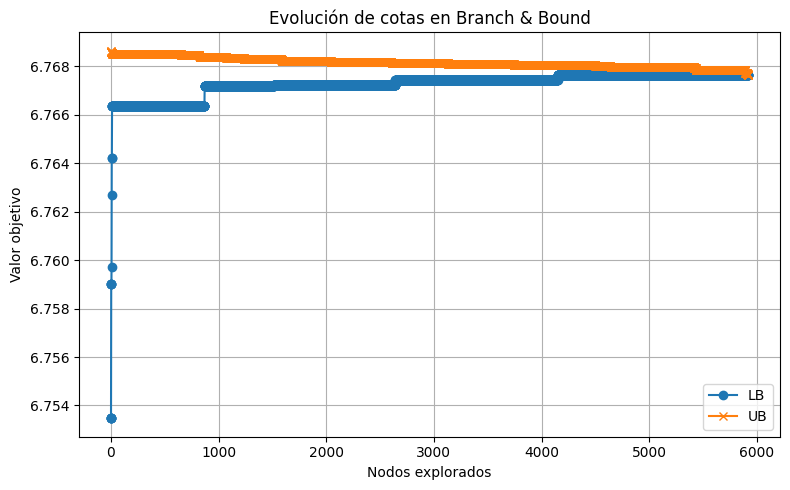

In [8]:
import matplotlib.pyplot as plt

# Gráfico de UB y LB
plt.figure(figsize=(8, 5))
plt.plot(m._nodes_hist[2:], np.log(m._lb_hist[2:]), label="LB", marker="o")
plt.plot(m._nodes_hist[2:], np.log(m._ub_hist[2:]), label="UB", marker="x")
plt.xlabel("Nodos explorados")
plt.ylabel("Valor objetivo")
plt.title("Evolución de cotas en Branch & Bound")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## *Lazy constraints* 

El ejemplo anterior se hizo mediante un problema de la mochila con pocas restricciones $(m=3)$. Sin embargo, es posible que se enfrenten con problemas con un número exponencial de restricciones, donde encontrar soluciones factibles sea muy complicado. 

Los *lazy constraints* son restricciones que no se incluyen al inicio del modelo, si no que se van incluyendo dinámicamente mientras se va ejecutando el Branch and Bound. La idea es que se intenta resolver el problema y llegar a una solución candidata (incumbente). Al llegar a la solución candidata se llama al callback para revisar si se viola alguna restricción que no fue añadida anteriormente. Si se viola, es posible llamar `model.cbLazy()` para añadir la restricción y volver a iterar. 

Primero, creemonos nuestra instancia con varias desigualdades

In [9]:
N = 150
M = 50

v, W, caps = instancia_knapsack(
    n=N, m=M, density=0.56, seed=42
)  # density más baja = más difícil
model = gp.Model("Ejemplo2")

params = {
    # === DESACTIVAR COSAS ===
    "Heuristics": 0.0,  # 0 desactiva heurísticas internas
    "Cuts": 0,  # 0 desactiva cortes
    "Presolve": 0,  # 0 desactiva presolve (2 agresivo, -1 auto)
    "Symmetry": 0,  # 0 desactiva detección de simetría
    "ConcurrentMIP": 1,  # 1 desactiva concurrente (corre estrategias distintas en paralelo)
    # === FOCO DE BÚSQUEDA ===
    "MIPFocus": 1,  # 0 auto, 1 incumbente rápido, 2 gap, 3 bound
    "VarBranch": 0,  # 0 auto, 1 max infeas, 2 pseudo cost; como se elige la variable actual para hacer branching
    "NodeMethod": 1,  # 1 dual simplex en nodos (0 auto, 2 barrier); como se resuelve el LP en los nodos
    "BranchDir": 0,  # 0 auto, 1 up, -1 down
    # === TOLERANCIAS ===
    "MIPGap": 0.0,  # gap objetivo relativo deseado (p.ej. 0.01 = 1%)
    "FeasibilityTol": 1e-6,  # tolerancia de viabilidad
    "IntFeasTol": 1e-5,  # tolerancia de integralidad
    "NumericFocus": 0,  # 0-3 (3 = más robusto numéricamente)
    # === LÍMITES Y LOG ===
    "TimeLimit": 60,  # seg. (0 = sin límite)
    "BestObjStop": None,  # para minimización: detiene al llegar a obj <= valor
    "BestBdStop": None,  # detiene si bound <= valor
    "Threads": 0,  # 0 = auto
    "Seed": 42,
    "LogToConsole": 1,  # 1 muestra log, 0 oculta
    "OutputFlag": 1,
    # Debemos activar lazy constraints
    "LazyConstraints": 1,
}

for k, a in params.items():
    if a is not None:
        model.setParam(k, a)

n = len(v)
x = model.addVars(n, vtype=GRB.BINARY, name="x")
model.setObjective(gp.quicksum(v[i] * x[i] for i in range(n)), GRB.MAXIMIZE)

# Para el callback
#
model._v = v
model._x = [x[i] for i in range(n)]
model._W = W
model._caps = caps
model._lazy_count = 0

# Históricos para gráficos
model._nodes_hist = []
model._lb_hist = []
model._ub_hist = []

# Métricas de lazy
model._lazy_count = 0
model._lazy_hist = []  # acumulado por evento MIP
model._lazy_per_event = []  # cuántas se agregaron en cada MIPSOL
model._violations = []  # lista de (t, j, violación)

Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Symmetry to value 0
Set parameter ConcurrentMIP to value 1
Set parameter MIPFocus to value 1
Set parameter VarBranch to value 0
Set parameter NodeMethod to value 1
Set parameter BranchDir to value 0
Set parameter MIPGap to value 0
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-05
Set parameter NumericFocus to value 0
Set parameter TimeLimit to value 60
Set parameter Threads to value 0
Set parameter Seed to value 42
Set parameter LogToConsole to value 1
Set parameter OutputFlag to value 1
Set parameter LazyConstraints to value 1


Noten que no hemos puesto las restricciones de capacidad acá, ya que las pondremos posteriormente con lazy constraints. 

In [10]:
def mip_callback(model, where):
    if where == GRB.Callback.MIP:

        nodes = model.cbGet(GRB.Callback.MIP_NODCNT)
        bestbd = model.cbGet(GRB.Callback.MIP_OBJBND)  # "best bound"
        bestst = model.cbGet(GRB.Callback.MIP_OBJBST)  # "best incumbent"

        # Detectar sentido: +1=minimiza, -1=maximiza
        sense = model.ModelSense
        if sense == -1:  # MAXIMIZAR
            LB, UB = bestst, bestbd  # inc es LB; bound es UB
        else:  # MINIMIZAR
            LB, UB = bestbd, bestst  # bound es LB; inc es UB

        # Guardar series para graficar después
        model._nodes_hist.append(nodes)
        model._lb_hist.append(LB)
        model._ub_hist.append(UB)
        # Llevar acumulado de lazy ya agregadas
        if hasattr(model, "_lazy_count"):
            model._lazy_hist.append(model._lazy_count)

    elif where == GRB.Callback.MIPNODE:

        status = model.cbGet(GRB.Callback.MIPNODE_STATUS)
        if status != GRB.OPTIMAL:  # Si no es un óptimo
            return

        # Solución LP fraccional del nodo
        x_rel = model.cbGetNodeRel(model._x)

        # Heurística: intenta obtener binaria factible
        x_bin = greedy_repair(
            np.array(x_rel, dtype=float), model._v, model._W, model._caps
        )

        # Si encontró factible, la proponemos como incumbente
        if x_bin is not None:
            try:
                model.cbSetSolution(model._x, x_bin.tolist())
            except Exception:
                pass  # si falla, seguimos sin interrumpir

    elif where == GRB.Callback.MIPSOL:
        try:
            x_sol = model.cbGetSolution(model._x)  # incumbente candidato (entero)
        except Exception:
            return

        W = model._W
        caps = model._caps
        n = len(x_sol)
        m = W.shape[0]

        added_now = 0
        for j in range(m):
            lhs = sum(W[j, i] * x_sol[i] for i in range(n))
            if lhs > caps[j] + 1e-9:
                # Agregar la capacidad como restricción LAZY
                model.cbLazy(sum(W[j, i] * model._x[i] for i in range(n)) <= caps[j])
                added_now += 1
                if hasattr(model, "_violations"):
                    # Guarda (evento, restricción, magnitud de la violación)
                    model._violations.append(
                        (len(model._nodes_hist), j, float(lhs - caps[j]))
                    )

        # Actualiza contadores/series para gráficos
        if hasattr(model, "_lazy_count"):
            model._lazy_count += added_now
        if hasattr(model, "_lazy_per_event"):
            model._lazy_per_event.append(added_now)

Y ahora, llamamos el optimizador:

In [11]:
model.optimize(mip_callback)

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0
MIPFocus  1
NodeMethod  1
Symmetry  0
VarBranch  0
Cuts  0
Presolve  0
Seed  42
LazyConstraints  1

Optimize a model with 0 rows, 150 columns and 0 nonzeros
Model fingerprint: 0x7f34480e
Variable types: 0 continuous, 150 integer (150 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e+01, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Variable types: 0 continuous, 150 integer (150 binary)

Root relaxation: objective 2.040052e+03, 0 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 2040.05176    0    -          - 2040.051

Se tendría el siguiente gráfico:

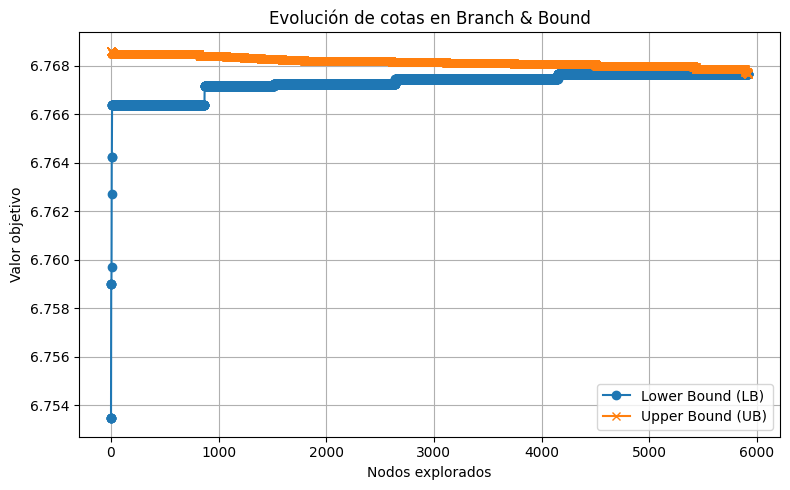

In [19]:
nodes = np.array(m._nodes_hist[6:])
lb    = np.array(m._lb_hist[6:])
ub    = np.array(m._ub_hist[6:])

plt.figure(figsize=(8,5))
plt.plot(nodes, np.log(lb), label="Lower Bound (LB)", marker="o")
plt.plot(nodes, np.log(ub), label="Upper Bound (UB)", marker="x")
plt.xlabel("Nodos explorados")
plt.ylabel("Valor objetivo")
plt.title("Evolución de cotas en Branch & Bound")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()